<a href="https://colab.research.google.com/github/faudhim5-buddy/belajar-ai-30-hari/blob/main/DAY_21_Minpro2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

data = {
    "pengalaman_python" : [1, 3, 5, 2, 7, 0, 4, 6, 1, 8,
                          2, 5, 3, 7, 1, 4, 6, 0, 3, 5],
    "pengetahuan_statistik" : [2, 4, 5, 3, 5, 1, 4, 5, 2, 5,
                               3, 4, 3, 5, 2, 4, 5, 1, 3, 4],
    "pengalaman_proyek" : [0, 2, 4, 1, 5, 0, 3, 4, 0, 5,
                          1, 3, 2, 5, 0, 2, 4, 0, 2, 3],
    "cocok" : ["tidak", "ya", "ya", "tidak", "ya",
              "tidak", "ya", "ya", "tidak", "ya",
              "tidak", "ya", "tidak", "ya", "tidak",
              "ya", "ya", "tidak", "tidak", "ya"]
}

df = pd.DataFrame(data)
print("Dataset : ")
print(df)
print()
print("Info dataset : ")
print(df.describe())

Dataset : 
    pengalaman_python  pengetahuan_statistik  pengalaman_proyek  cocok
0                   1                      2                  0  tidak
1                   3                      4                  2     ya
2                   5                      5                  4     ya
3                   2                      3                  1  tidak
4                   7                      5                  5     ya
5                   0                      1                  0  tidak
6                   4                      4                  3     ya
7                   6                      5                  4     ya
8                   1                      2                  0  tidak
9                   8                      5                  5     ya
10                  2                      3                  1  tidak
11                  5                      4                  3     ya
12                  3                      3                  2  t

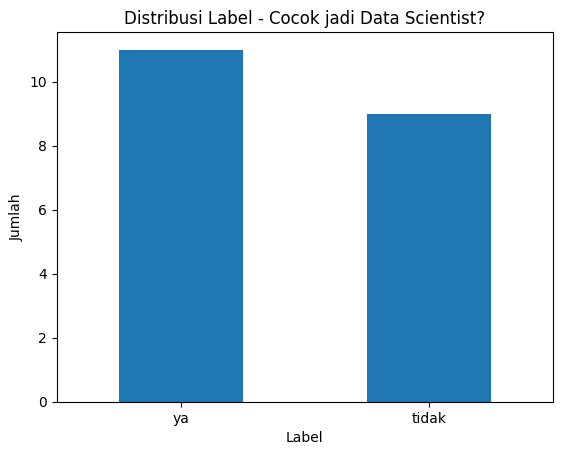

Jumlah tiap label
cocok
ya       11
tidak     9
Name: count, dtype: int64


In [ ]:
from numpy._core.multiarray import asanyarray
import pandas as pd
import matplotlib.pyplot as plt


data = {
    "pengalaman_python": [1, 3, 5, 2, 7, 0, 4, 6, 1, 8,
                          2, 5, 3, 7, 1, 4, 6, 0, 3, 5],
    "pengetahuan_statistik": [2, 4, 5, 3, 5, 1, 4, 5, 2, 5,
                               3, 4, 3, 5, 2, 4, 5, 1, 3, 4],
    "pengalaman_proyek": [0, 2, 4, 1, 5, 0, 3, 4, 0, 5,
                          1, 3, 2, 5, 0, 2, 4, 0, 2, 3],
    "cocok": ["tidak", "ya", "ya", "tidak", "ya",
              "tidak", "ya", "ya", "tidak", "ya",
              "tidak", "ya", "tidak", "ya", "tidak",
              "ya", "ya", "tidak", "tidak", "ya"]
}

df = pd.DataFrame(data)

df["cocok"].value_counts().plot(kind="bar")
plt.title("Distribusi Label - Cocok jadi Data Scientist?")
plt.xlabel("Label")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)
plt.show()

print("Jumlah tiap label")
print(df["cocok"].value_counts())

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report

data = {"pengalaman_python": [1, 3, 5, 2, 7, 0, 4, 6, 1, 8,
                          2, 5, 3, 7, 1, 4, 6, 0, 3, 5],
    "pengetahuan_statistik": [2, 4, 5, 3, 5, 1, 4, 5, 2, 5,
                               3, 4, 3, 5, 2, 4, 5, 1, 3, 4],
    "pengalaman_proyek": [0, 2, 4, 1, 5, 0, 3, 4, 0, 5,
                          1, 3, 2, 5, 0, 2, 4, 0, 2, 3],
    "cocok": ["tidak", "ya", "ya", "tidak", "ya",
              "tidak", "ya", "ya", "tidak", "ya",
              "tidak", "ya", "tidak", "ya", "tidak",
              "ya", "ya", "tidak", "tidak", "ya"]
}

df = pd.DataFrame(data)

X = df[["pengalaman_python", "pengetahuan_statistik", "pengalaman_proyek"]]
y = df["cocok"]

X_latih, X_uji, y_latih, y_uji = train_test_split(
    X, y, test_size=0.4, random_state=42)

scaler = MinMaxScaler()
X_latih_normal = scaler.fit_transform(X_latih)
X_uji_normal = scaler.transform(X_uji)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_latih_normal, y_latih)

akurasi = accuracy_score(y_latih, model.predict(X_latih_normal))
cv_scores = cross_val_score(model, X, y, cv=5)

print("Akurasi data uji:", akurasi*100, "%")
print("Cross validation:", cv_scores.mean() *100, "%")
print()
print(classification_report(y_uji, model.predict(X_uji_normal)))

Akurasi data uji: 100.0 %
Cross validation: 95.0 %

              precision    recall  f1-score   support

       tidak       0.83      1.00      0.91         5
          ya       1.00      0.67      0.80         3

    accuracy                           0.88         8
   macro avg       0.92      0.83      0.85         8
weighted avg       0.90      0.88      0.87         8



In [ ]:
import numpy as np

kandidat = np.array([
    [5,4,3],
    [0,1,0],
    [7,5,5],
    [2,2,1],
])

kandidat_normal = scaler.transform(kandidat)
prediksi = model.predict(kandidat_normal)
probabilitas = model.predict_proba(kandidat_normal)

print("Hasil prediksi kandidat:")
print("_" *50)
for i, pred in enumerate(prediksi):
  prob = probabilitas[i]
  print(f" Kandidat {i+1}:")
  print(f" Python: {kandidat[i][0]} tahun | Statistik: {kandidat[i][0]}/5 | Proyek: {kandidat[i][2]}")
  print(f" Prediksi: {pred}")
  print(f" Keyakinan: {max(prob)*100:.1f}%")
  print()

Hasil prediksi kandidat:
__________________________________________________
 Kandidat 1:
 Python: 5 tahun | Statistik: 5/5 | Proyek: 3
 Prediksi: ya
 Keyakinan: 100.0%

 Kandidat 2:
 Python: 0 tahun | Statistik: 0/5 | Proyek: 0
 Prediksi: tidak
 Keyakinan: 99.0%

 Kandidat 3:
 Python: 7 tahun | Statistik: 7/5 | Proyek: 5
 Prediksi: ya
 Keyakinan: 100.0%

 Kandidat 4:
 Python: 2 tahun | Statistik: 2/5 | Proyek: 1
 Prediksi: tidak
 Keyakinan: 99.0%



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
